### LangChains Expression Language

In [1]:
import os

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_PROJECT"] = "learning"

### Traditional Chains vs LCEL

In this section we're going to dive into a basic example using the traditional method for building chains before jumping into LCEL. We will build a pipeline where the user must input a specific topic, and then the LLM will look and return a report on the specified topic. Generating a research report for the user.

In [2]:
from langchain_openai import ChatOpenAI
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
load_dotenv()

creative_llm = ChatOpenAI(
    model="gpt-5-mini",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
    temperature=0.9
)

llm = ChatOpenAI(
    model="gpt-3.5-turbo",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
    temperature=0.0
)
llm1 = ChatOpenRouter(
    model = "openai/gpt-oss-20b"
)
llm2 = ChatOpenRouter(
    model = "nvidia/nemotron-nano-9b-v2"
)

/home/harsh.dhandha@simform.dom/hh/GenAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from langchain_classic import PromptTemplate

prompt_template = "Give me a small report on {topic}"

prompt = PromptTemplate(
    input_variables=["topic"],
    template=prompt_template
)

In [7]:
llm_out = llm.invoke("Hello there")
llm_out

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 9, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-Dgpn2gg7cNlVMI7BnUxCtXhvOmIoS', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3ab2-5b2b-7d63-83a6-f4f86f315643-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 10, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [9]:
from langchain_classic.schema.output_parser import StrOutputParser

output_parser = StrOutputParser()

In [10]:
out = output_parser.invoke(llm_out)
out

'Hello! How can I assist you today?'

In [11]:
from langchain_classic.chains import LLMChain

chain = LLMChain(prompt=prompt, llm=llm, output_parser=output_parser)

/tmp/ipykernel_274734/1812892885.py:3: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 2.0.0. Use `RunnableSequence, e.g., `prompt | llm`` instead.
  chain = LLMChain(prompt=prompt, llm=llm, output_parser=output_parser)


In [12]:
res =  chain.invoke("RAG")
res

{'topic': 'RAG',
 'text': '### Report on RAG (Retrieval-Augmented Generation)\n\n#### Introduction\nRetrieval-Augmented Generation (RAG) is an advanced approach in natural language processing (NLP) that combines the strengths of retrieval-based and generative models. It aims to enhance the quality and relevance of generated text by incorporating external knowledge from a large corpus of documents.\n\n#### Key Components\n1. **Retrieval Mechanism**: RAG utilizes a retrieval system to fetch relevant documents or passages from a large database based on the input query. This is typically achieved using techniques such as dense vector representations and similarity search.\n\n2. **Generative Model**: After retrieving relevant information, RAG employs a generative model (often based on transformer architectures like BERT or GPT) to produce coherent and contextually appropriate responses. The generative model uses the retrieved documents as additional context to improve the quality of the out

In [14]:
from IPython.display import display, Markdown

display(Markdown(res["text"]))

### Report on RAG (Retrieval-Augmented Generation)

#### Introduction
Retrieval-Augmented Generation (RAG) is an advanced approach in natural language processing (NLP) that combines the strengths of retrieval-based and generative models. It aims to enhance the quality and relevance of generated text by incorporating external knowledge from a large corpus of documents.

#### Key Components
1. **Retrieval Mechanism**: RAG utilizes a retrieval system to fetch relevant documents or passages from a large database based on the input query. This is typically achieved using techniques such as dense vector representations and similarity search.

2. **Generative Model**: After retrieving relevant information, RAG employs a generative model (often based on transformer architectures like BERT or GPT) to produce coherent and contextually appropriate responses. The generative model uses the retrieved documents as additional context to improve the quality of the output.

3. **End-to-End Training**: RAG models can be trained end-to-end, allowing the retrieval and generation components to learn from each other. This integration helps in optimizing the overall performance of the system.

#### Advantages
- **Improved Relevance**: By leveraging external knowledge, RAG can provide more accurate and contextually relevant responses compared to traditional generative models that rely solely on their training data.
- **Dynamic Knowledge Integration**: RAG can access up-to-date information from external sources, making it suitable for applications that require current knowledge, such as customer support or information retrieval systems.
- **Flexibility**: The architecture can be adapted for various tasks, including question answering, summarization, and dialogue systems.

#### Applications
- **Question Answering**: RAG is particularly effective in systems that need to answer questions based on a vast amount of information, such as search engines and virtual assistants.
- **Content Creation**: It can assist in generating articles, reports, or summaries by pulling in relevant data from multiple sources.
- **Chatbots**: RAG enhances the conversational abilities of chatbots by providing them with access to a broader knowledge base.

#### Challenges
- **Complexity**: The integration of retrieval and generation components can complicate the training and deployment of RAG models.
- **Latency**: The retrieval process may introduce latency, which can be a concern in real-time applications.
- **Quality of Retrieved Information**: The effectiveness of RAG heavily depends on the quality and relevance of the retrieved documents. Poor retrieval can lead to suboptimal generation.

#### Conclusion
Retrieval-Augmented Generation represents a significant advancement in the field of NLP, combining the strengths of retrieval and generative models to produce high-quality, contextually relevant text. As research and development in this area continue, RAG is expected to play a crucial role in various applications, enhancing the capabilities of AI systems in understanding and generating human-like text.

### LangChain Expression Language (LCEL)

LangChain Expression Language (LCEL) is the recommended approach to building chains in LangChain. Having superceeded the traditional methods with LLMChain, etc. LCEL gives us a more flexible system for building chains. The pipe operator | is used by LCEL to chain together components. Let's see how we'd construct an LLMChain using LCEL.

In [16]:
lcel_chain = prompt | llm | output_parser
res=lcel_chain.invoke("RAG")

In [17]:
res

'### Report on RAG (Retrieval-Augmented Generation)\n\n#### Introduction\nRetrieval-Augmented Generation (RAG) is an advanced approach in natural language processing (NLP) that combines the strengths of retrieval-based and generative models. It aims to enhance the quality and relevance of generated text by incorporating external knowledge from a large corpus of documents.\n\n#### Key Components\n1. **Retrieval Mechanism**: RAG utilizes a retrieval system to fetch relevant documents or passages from a large database based on the input query. This is typically achieved using techniques such as dense vector representations and similarity search.\n\n2. **Generative Model**: After retrieving relevant information, RAG employs a generative model (often based on transformer architectures like BERT or GPT) to produce coherent and contextually appropriate responses. The generative model uses the retrieved documents as additional context to improve the output.\n\n3. **End-to-End Training**: RAG m

In [18]:
display(Markdown(res))

### Report on RAG (Retrieval-Augmented Generation)

#### Introduction
Retrieval-Augmented Generation (RAG) is an advanced approach in natural language processing (NLP) that combines the strengths of retrieval-based and generative models. It aims to enhance the quality and relevance of generated text by incorporating external knowledge from a large corpus of documents.

#### Key Components
1. **Retrieval Mechanism**: RAG utilizes a retrieval system to fetch relevant documents or passages from a large database based on the input query. This is typically achieved using techniques such as dense vector representations and similarity search.

2. **Generative Model**: After retrieving relevant information, RAG employs a generative model (often based on transformer architectures like BERT or GPT) to produce coherent and contextually appropriate responses. The generative model uses the retrieved documents as additional context to improve the output.

3. **End-to-End Training**: RAG models can be trained end-to-end, allowing the retrieval and generation components to learn from each other. This integration helps optimize the overall performance of the system.

#### Advantages
- **Improved Relevance**: By leveraging external knowledge, RAG can provide more accurate and contextually relevant responses compared to traditional generative models that rely solely on their training data.
- **Dynamic Knowledge Integration**: RAG can access up-to-date information from the retrieval corpus, making it suitable for applications requiring current knowledge.
- **Flexibility**: The architecture can be adapted for various tasks, including question answering, summarization, and dialogue systems.

#### Applications
- **Question Answering**: RAG is particularly effective in systems that need to answer questions based on a vast amount of information, such as customer support bots or educational tools.
- **Content Generation**: It can be used to generate articles, reports, or summaries that require factual accuracy and relevance.
- **Conversational Agents**: RAG enhances chatbots and virtual assistants by providing them with the ability to pull in relevant information during interactions.

#### Challenges
- **Complexity**: The integration of retrieval and generation components can complicate the training and deployment processes.
- **Latency**: The retrieval step may introduce latency, which can be a concern for real-time applications.
- **Quality of Retrieved Information**: The effectiveness of RAG heavily depends on the quality and relevance of the retrieved documents.

#### Conclusion
Retrieval-Augmented Generation represents a significant advancement in the field of NLP, combining the strengths of retrieval and generative models to produce high-quality, contextually relevant text. As research and development in this area continue, RAG is likely to play a crucial role in the evolution of intelligent systems capable of understanding and generating human-like text.

In [19]:


class Runnable:
    def __init__(self, func):
        self.func = func
    def __or__(self, other):
        def chained_func(*args, **kwargs):
            return other.invoke(self.func(*args, **kwargs))
        return Runnable(chained_func)
    def invoke(self, *args, **kwargs):
        return self.func(*args, **kwargs)



In [20]:
def add_five(x):
    return x+5

def sub_five(x):
    return x-5

def mul_five(x):
    return x*5

In [21]:
add_five_runnable = Runnable(add_five)
sub_five_runnable = Runnable(sub_five)
mul_five_runnable = Runnable(mul_five)

In [22]:


chain = (add_five_runnable).__or__(sub_five_runnable).__or__(mul_five_runnable)

chain.invoke(3)



15

In [23]:
chain = add_five_runnable | sub_five_runnable | mul_five_runnable

chain.invoke(3)

15

### LCEL RunnableLambda

The RunnableLambda class is LangChain's built-in method for constructing a runnable object from a function. That is, it does the same thing as the custom Runnable class we created earlier. Let's try it out with the same functions as before.

In [24]:


from langchain_core.runnables import RunnableLambda

add_five_runnable = RunnableLambda(add_five)
sub_five_runnable = RunnableLambda(sub_five)
mul_five_runnable = RunnableLambda(mul_five)



In [25]:


chain = add_five_runnable | sub_five_runnable | mul_five_runnable



In [26]:
chain.invoke(3)

15

In [27]:
prompt_str = "give me a small report about {topic}"
prompt = PromptTemplate(
    input_variables=["topic"],
    template=prompt_str
)



In [28]:
chain = prompt | llm | output_parser

In [29]:
result = chain.invoke("AI")
display(Markdown(result))

### Report on Artificial Intelligence (AI)

#### Introduction

Artificial Intelligence (AI) refers to the simulation of human intelligence processes by machines, particularly computer systems. These processes include learning (the acquisition of information and rules for using it), reasoning (using rules to reach approximate or definite conclusions), and self-correction. The field of AI encompasses a variety of sub-disciplines, including machine learning, natural language processing, robotics, and computer vision.

#### Current State of AI

As of 2023, AI technology has witnessed rapid advancements, marking a transformative impact across multiple sectors, including healthcare, finance, transportation, and education. Key developments include:

1. **Machine Learning**: Algorithms enable computers to learn from and make predictions based on data. Deep learning, a subset of machine learning, uses neural networks with many layers and has led to breakthroughs in image and speech recognition.

2. **Natural Language Processing (NLP)**: AI systems are increasingly capable of understanding and generating human language. Applications include chatbots, virtual assistants, and automated translation services.

3. **Computer Vision**: AI techniques help machines interpret and understand visual information from the world, facilitating advancements in autonomous vehicles, facial recognition, and medical imaging analysis.

4. **Robotics**: AI is integrated into robotics for tasks ranging from manufacturing automation to personal assistants and exploration in hazardous environments.

#### Applications of AI

- **Healthcare**: AI enhances diagnostic accuracy, personalizes treatment options, and streamlines administrative tasks. Predictive analytics are used for patient care management and drug discovery.
  
- **Finance**: AI assists in fraud detection, algorithmic trading, and customer service through chatbots, improving operational efficiency and user experience.

- **Transportation**: Self-driving cars leverage AI for navigation and safety, while predictive algorithms optimize traffic flow and public transportation systems.

- **Education**: AI-driven platforms provide personalized learning experiences, adaptive assessments, and administrative efficiencies, enhancing student engagement and educational outcomes.

#### Challenges and Ethics

Despite its potential, AI poses several challenges, particularly regarding ethical considerations, privacy, and job displacement. Key concerns include:

- **Bias and Fairness**: AI systems can inadvertently perpetuate biases present in their training data, leading to unfair outcomes in critical areas like hiring and law enforcement.
  
- **Data Privacy**: The collection and use of personal data raise concerns about consent and security, necessitating robust regulatory frameworks.

- **Job Displacement**: Automation driven by AI may lead to significant job losses in specific sectors, creating a need for reskilling and workforce adaptation strategies.

#### Conclusion

AI has the potential to revolutionize many aspects of society, driving innovation and efficiency across industries. However, to harness its benefits responsibly, careful consideration of ethical implications, governance, and societal impact is essential. Continuous dialogue among stakeholders, including technologists, policymakers, and the public, is critical in shaping a future where AI is used effectively and ethically.

In [35]:
def extract_fact(x):
    if "\n\n" in x:
        return "\n".join(x.split("\n\n")[1:])
    else:
        return x

old_word = "AI"
new_word = "skynet"

def replace_word(x):
    return x.replace(old_word ,new_word)

In [36]:
extract_fact_runnable= RunnableLambda(extract_fact)
replace_word_runnable= RunnableLambda(replace_word)

In [37]:
chain = prompt | llm | output_parser | extract_fact_runnable | replace_word_runnable

In [38]:
res = prompt | llm | output_parser | extract_fact_runnable | replace_word_runnable

In [40]:
res = chain.invoke("GTA")
display(Markdown(res))

**Introduction**
Grand Theft Auto (GTA) is a critically acclaimed action-adventure video game franchise created by David Jones and Mike Dailly, and is produced and published by Rockstar Games. The series debuted in 1997 and has since evolved into one of the most popular and commercially successful video game franchises in history. Known for its open-world gameplay, engaging narratives, and controversial themes, GTA has influenced the gaming industry significantly.
**Gameplay Mechanics**
GTA games are notable for their open-world design, allowing players to explore vast, immersive environments based on real-world locations. Players can engage in missions that advance the story, participate in side activities, and interact with non-playable characters (NPCs). The games typically feature a combination of driving, shooting, and role-playing elements, providing players with a range of gameplay experiences.
**Story and Themes**
Each installment in the GTA series typically follows a protagonist involved in criminal activities within a fictional city. The narratives often explore themes of crime, morality, and the impact of society on individual choices. The storytelling is enhanced by well-developed characters and satirical commentary on contemporary issues, including politics, culture, and media.
**Major Installments**
Key titles in the franchise include:
- **GTA III (2001)**: This title marked the series' transition to 3D graphics and introduced players to Liberty City, setting the standard for future open-world games.
- **GTA: Vice City (2002)**: Set in a vibrant, 1980s-inspired Miami, this installment became famous for its nostalgic atmosphere and engaging storyline.
- **GTA: San Andreas (2004)**: Known for its vast open world and RPG elements, San Andreas offered players unprecedented freedom and depth in gameplay.
- **GTA V (2013)**: One of the most successful video games of all time, GTA V features three playable protagonists and a sprawling, dynamic world. Its online multiplayer component, GTA Online, has contributed to its sustained popularity and revenue.
**Controversy and Impact**
GTA has faced criticism over the years for its portrayal of violence, crime, and controversial themes. Critics often point to its mature content, arguing that it can influence negative behavior in players. However, defenders of the series argue that it serves as social commentary and that players can distinguish between the game and reality.
Despite the controversies, GTA has received numerous awards and accolades, underscoring its impact on gaming culture and its role as a pioneering force in the open-world genre.
**Conclusion**
Grand Theft Auto remains a landmark franchise in the gaming industry, renowned for its engaging gameplay, rich storytelling, and cultural significance. As it continues to evolve with new titles and updates, GTA's influence is likely to be felt for many years to come.

### LCEL RunnableParallel and RunnablePassthrough


LCEL provides us with various Runnable classes that allow us to control the flow of data and execution order through our chains. Two of these are RunnableParallel and RunnablePassthrough.

    RunnableParallel — allows us to run multiple Runnable instances in parallel. Acting almost as a Y-fork in the chain.

    RunnablePassthrough — allows us to pass through a variable to the next Runnable without modification.



In [45]:
from langchain_classic.embeddings import OpenAIEmbeddings
from langchain_classic.vectorstores import DocArrayInMemorySearch

em =  OpenAIEmbeddings(api_key=os.getenv("API_KEY"), base_url = os.getenv("BASE_URL"))

vecstore_a = DocArrayInMemorySearch.from_texts(
    [
        "half the info is here",
        "DeepSeek-V3 was released in December 2024"
    ],
    embedding=em
)
vecstore_b = DocArrayInMemorySearch.from_texts(
    [
        "the other half of the info is here",
        "the DeepSeek-V3 LLM is a mixture of experts model with 671B parameters"
    ],
    embedding=em
)

/home/harsh.dhandha@simform.dom/hh/GenAI/.venv/lib/python3.12/site-packages/docarray/helper.py:255: SyntaxWarning: invalid escape sequence '\*'
  e.g. '\*.py', '[\*.zip, \*.gz]'


In [46]:
prompt_str = """Using the context provided, answer the user's question.
Context:
{context_a}
{context_b}
"""


In [48]:
from langchain_classic.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate

prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(prompt_str),
    HumanMessagePromptTemplate.from_template("{question}")
])

In [49]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

retriever_a = vecstore_a.as_retriever()
retriever_b = vecstore_b.as_retriever()

retrieval = RunnableParallel(
    {
        "context_a": retriever_a, "context_b": retriever_b, "question": RunnablePassthrough()
    }
)

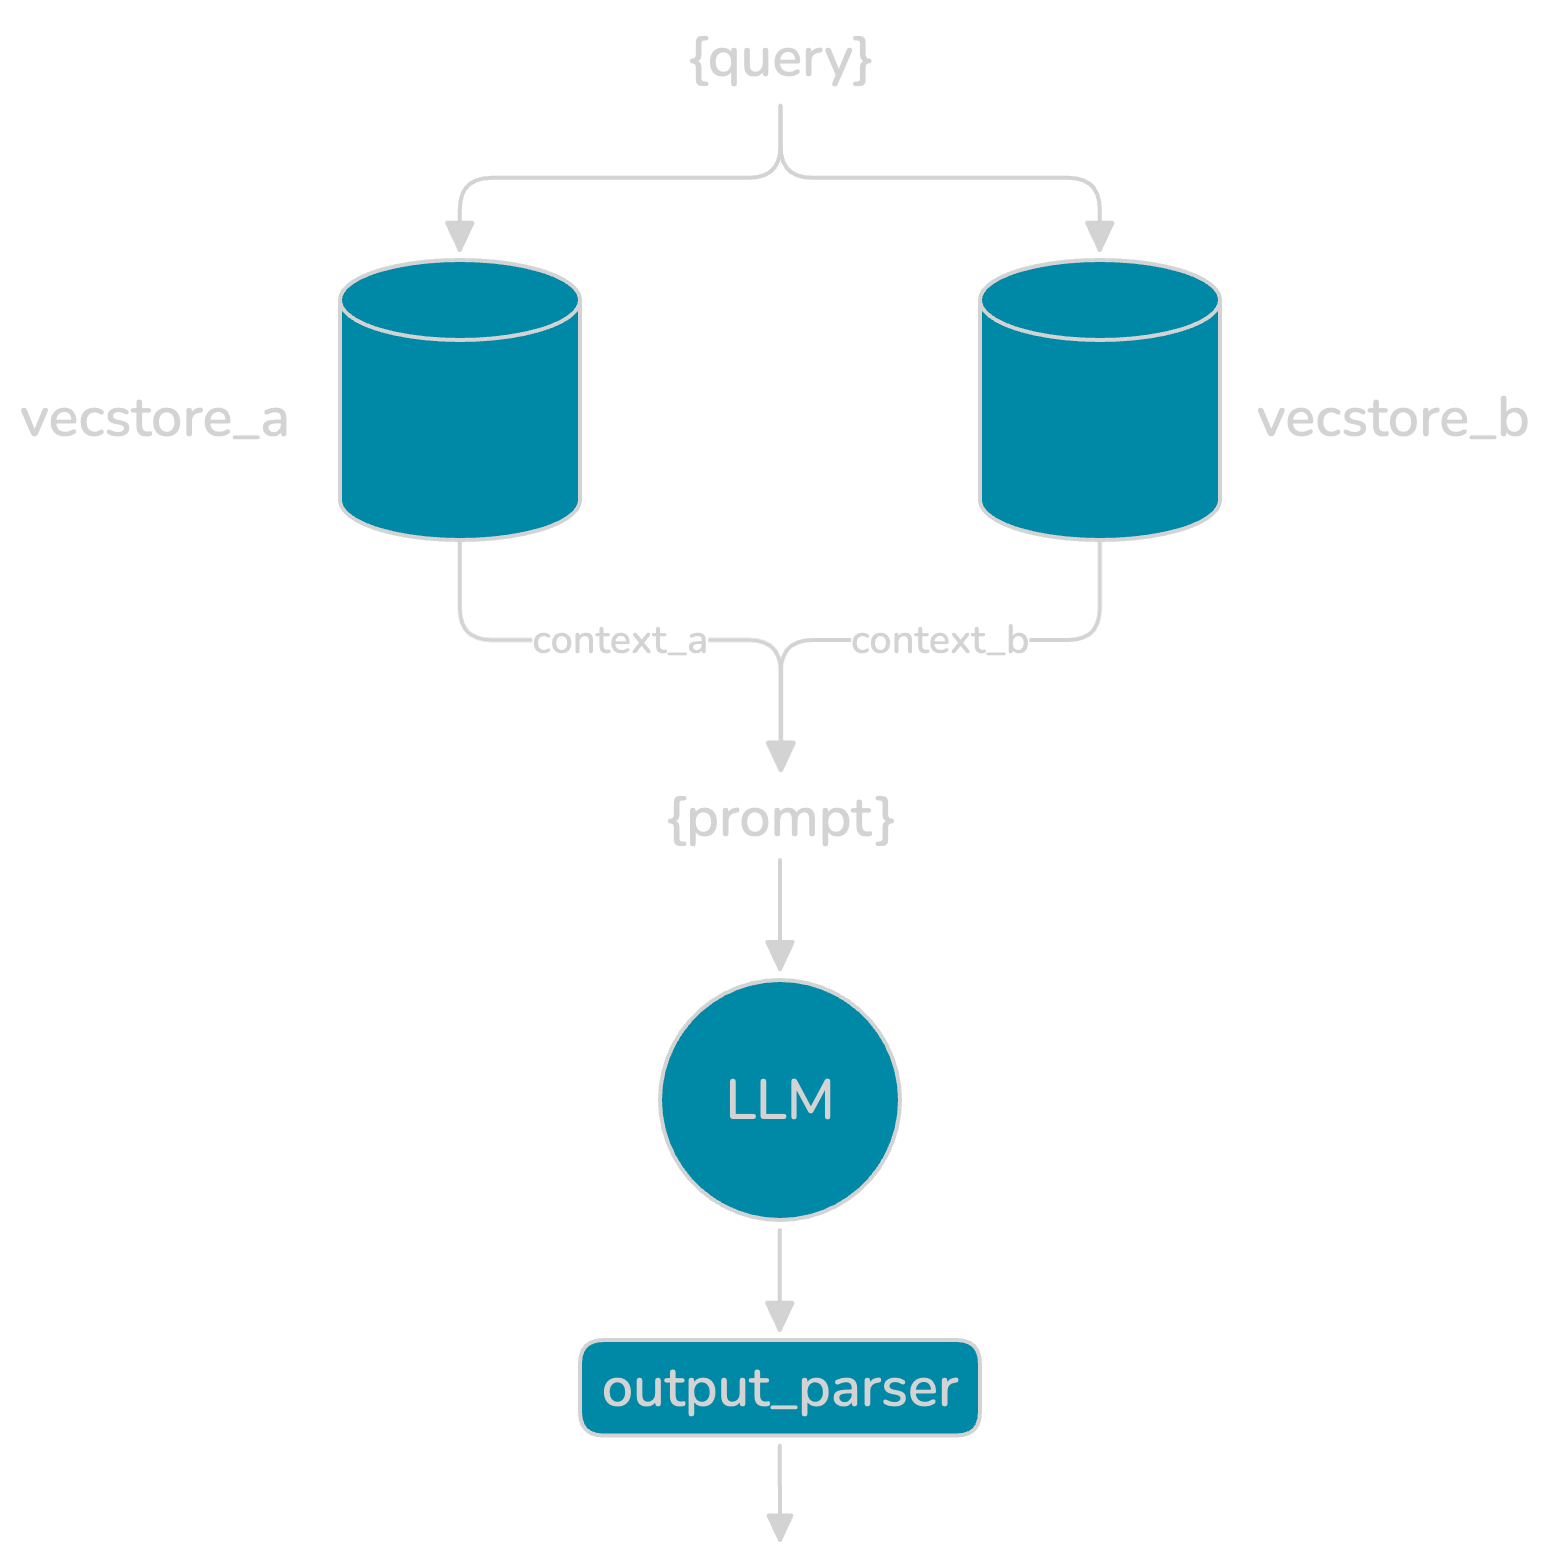

In [50]:


chain = retrieval | prompt | llm | output_parser



In [51]:


result = chain.invoke(
    "what architecture does the model DeepSeek released in december use?"
)
result



'DeepSeek-V3 uses a mixture of experts model architecture with 671 billion parameters.'